Prédiction de la performance financière des entreprises marocaines
Par **ILBOUDO WENDKOUNI ELISEE_ CAC2_ 22007857**

# 📈 Modèle Prédictif des Prix des Actions — Horizons 15 Jours

> **Auteur :** Expert Senior en Quantitative Finance & Data Science  
> **Objectif :** Prédire les 15 prochains jours de prix d'actions avec un modèle dont la précision s'affine à mesure que la date approche.

---

### 🏗️ Architecture du Notebook

| Étape | Description |
|-------|-------------|
| **1** | ⚙️ Installation & Configuration Google Colab |
| **2** | 📊 EDA & Nettoyage des données |
| **3** | 🔧 Feature Engineering Avancé |
| **4** | 🤖 Entraînement du Modèle ML (XGBoost) |
| **5** | 🔮 Prédiction 15 jours avec logique de confiance |
| **6** | 📉 Visualisations interactives |

---
### 📌 Concept Clé : Logique d'Affinage par Proximité

Le modèle utilise une **fenêtre glissante temporellement pondérée** :  
- **J+1 / J+2** : Prédiction basée sur les données les plus récentes → faible variance → haute précision  
- **J+15** : Propagation d'incertitudes accumulées → intervalle de confiance plus large

Ce comportement reflète la réalité financière : *l'horizon de prévision est inversement corrélé à la précision*.

## ⚙️ ÉTAPE 1 — Installation des Dépendances & Configuration Colab

In [ ]:
# ==============================================================================
# 📦 INSTALLATION DES BIBLIOTHÈQUES NON-NATIVES
# Exécuter cette cellule en premier — redémarrer le runtime si demandé
# ==============================================================================

!pip install -q xgboost lightgbm plotly scikit-learn pandas numpy matplotlib seaborn
!pip install -q gdown  # Pour télécharger depuis Google Drive

print('✅ Toutes les bibliothèques sont installées avec succès !')

✅ Toutes les bibliothèques sont installées avec succès !


In [ ]:
# ==============================================================================
# 📂 ACCÈS AUX DONNÉES — GOOGLE DRIVE
# Deux méthodes disponibles : montage Drive OU téléchargement direct
# ==============================================================================

import os

# -----------------------------------------------------------------------
# MÉTHODE A : Téléchargement direct depuis l'URL Google Drive (RECOMMANDÉ)
# -----------------------------------------------------------------------
GDRIVE_FILE_ID = '1nhK4jq_UTkaGZz79yNyoHR1S-hmvicBD'
LOCAL_FILENAME = 'stocks.csv'

if not os.path.exists(LOCAL_FILENAME):
    print('📥 Téléchargement du dataset depuis Google Drive...')
    import gdown
    url = f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}'
    gdown.download(url, LOCAL_FILENAME, quiet=False)
    print(f'✅ Fichier téléchargé : {LOCAL_FILENAME}')
else:
    print(f'✅ Fichier déjà présent : {LOCAL_FILENAME}')

FILE_PATH = LOCAL_FILENAME  # ← Modifier si vous utilisez un autre chemin

# -----------------------------------------------------------------------
# MÉTHODE B : Montage Google Drive (décommenter si préféré)
# -----------------------------------------------------------------------
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = '/content/drive/MyDrive/stocks.csv'  # ← Adapter le chemin

print(f'\n📌 Chemin du fichier utilisé : {FILE_PATH}')

📥 Téléchargement du dataset depuis Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1nhK4jq_UTkaGZz79yNyoHR1S-hmvicBD
To: /content/stocks.csv
100%|██████████| 576k/576k [00:00<00:00, 38.5MB/s]

✅ Fichier téléchargé : stocks.csv

📌 Chemin du fichier utilisé : stocks.csv


## 📦 ÉTAPE 2 — Importation des Bibliothèques

In [ ]:
# ==============================================================================
# 📚 IMPORTS CENTRALISÉS
# ==============================================================================

# --- Manipulation de données ---
import pandas as pd
import numpy as np
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# --- Visualisation ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# --- Machine Learning ---
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# --- Configuration globale ---
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Couleurs du thème ---
COLORS = {
    'primary':   '#00D4FF',
    'secondary': '#FF6B6B',
    'success':   '#00FF88',
    'warning':   '#FFD700',
    'bg':        '#1E1E2E',
    'grid':      '#2A2A3E'
}

print('✅ Bibliothèques chargées avec succès !')
print(f'   → Pandas  : {pd.__version__}')
print(f'   → NumPy   : {np.__version__}')
print(f'   → XGBoost : importé')

✅ Bibliothèques chargées avec succès !
   → Pandas  : 2.2.2
   → NumPy   : 2.0.2
   → XGBoost : importé


## 📊 ÉTAPE 3 — EDA & Nettoyage des Données

In [ ]:
# ==============================================================================
# 📥 CHARGEMENT & INSPECTION INITIALE
# ==============================================================================

df_raw = pd.read_csv(FILE_PATH)

print('=' * 60)
print('📋 APERÇU DU DATASET BRUT')
print('=' * 60)
print(f'\n📐 Dimensions : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
print(f'\n📑 Colonnes disponibles :')
for col in df_raw.columns:
    print(f'   • {col} ({df_raw[col].dtype})')

print('\n' + '─' * 60)
print('🔍 5 premières lignes :')
display(df_raw.head())

print('\n' + '─' * 60)
print('📉 5 dernières lignes :')
display(df_raw.tail())

📋 APERÇU DU DATASET BRUT

📐 Dimensions : 1,244 lignes × 1 colonnes

📑 Colonnes disponibles :
   • date;Addoha;AFMA;Afric Indus;Afriquia Gaz;Agma;Alliances;Aluminium Maroc;Aradei Capital;ATLANTASANAD;Attijariwafa;Auto Hall;Auto Nejma;BALIMA;BCP;BMCI;Cartier Saada;CDM;Central.Danone;CIH;Ciments Maroc;CMT;Colorado;COSUMAR;CTM;Dari Couspate;Delattre Lev;Delta Holding;Diac Salaf;DISWAY;Ennakl;EQDOM;FENIE BROSSETTE;HPS;IBMaroc;Immr Invest;INVOLYS;Jet Contractors;LABEL VIE;LafargeHolcim;Lesieur Cristal;Lydec;M2M Group;Maghreb Oxygene;Maghrebail;Managem;Maroc Leasing;Maroc Telecom;Med Paper;Microdata;Mutandis;Nexans Maroc;Oulmes;PROMOPHARM;Rebab Company;Res.Dar Saada;Risma;S2M;Saham Assurance;SALAFIN;SAMIR;SMI;Stokvis Nord Afr;SNEP;SODEP;Sonasid;SRM;Ste Boissons;STROC Indus;TAQA Morocco;Timar;Total Maroc;Unimer;Wafa Assur;Zellidja;MASI (object)

────────────────────────────────────────────────────────────
🔍 5 premières lignes :


,date;Addoha;AFMA;Afric Indus;Afriquia Gaz;Agma;Alliances;Aluminium Maroc;Aradei Capital;ATLANTASANAD;Attijariwafa;Auto Hall;Auto Nejma;BALIMA;BCP;BMCI;Cartier Saada;CDM;Central.Danone;CIH;Ciments Maroc;CMT;Colorado;COSUMAR;CTM;Dari Couspate;Delattre Lev;Delta Holding;Diac Salaf;DISWAY;Ennakl;EQDOM;FENIE BROSSETTE;HPS;IBMaroc;Immr Invest;INVOLYS;Jet Contractors;LABEL VIE;LafargeHolcim;Lesieur Cristal;Lydec;M2M Group;Maghreb Oxygene;Maghrebail;Managem;Maroc Leasing;Maroc Telecom;Med Paper;Microdata;Mutandis;Nexans Maroc;Oulmes;PROMOPHARM;Rebab Company;Res.Dar Saada;Risma;S2M;Saham Assurance;SALAFIN;SAMIR;SMI;Stokvis Nord Afr;SNEP;SODEP;Sonasid;SRM;Ste Boissons;STROC Indus;TAQA Morocco;Timar;Total Maroc;Unimer;Wafa Assur;Zellidja;MASI
0,16/01/2017;54.87;822.5;315.35;;;128.0;1150.0;;...
1,17/01/2017;51.5;822.5;315.35;;;128.55;1150.0;;...
2,18/01/2017;52.0;823.0;320.0;;;130.0;1150.0;;47...
3,19/01/2017;52.0;805.1;300.0;;;131.45;1180.0;;4...
4,20/01/2017;53.0;830.0;295.0;;2460.0;131.0;1150...



────────────────────────────────────────────────────────────
📉 5 dernières lignes :


,date;Addoha;AFMA;Afric Indus;Afriquia Gaz;Agma;Alliances;Aluminium Maroc;Aradei Capital;ATLANTASANAD;Attijariwafa;Auto Hall;Auto Nejma;BALIMA;BCP;BMCI;Cartier Saada;CDM;Central.Danone;CIH;Ciments Maroc;CMT;Colorado;COSUMAR;CTM;Dari Couspate;Delattre Lev;Delta Holding;Diac Salaf;DISWAY;Ennakl;EQDOM;FENIE BROSSETTE;HPS;IBMaroc;Immr Invest;INVOLYS;Jet Contractors;LABEL VIE;LafargeHolcim;Lesieur Cristal;Lydec;M2M Group;Maghreb Oxygene;Maghrebail;Managem;Maroc Leasing;Maroc Telecom;Med Paper;Microdata;Mutandis;Nexans Maroc;Oulmes;PROMOPHARM;Rebab Company;Res.Dar Saada;Risma;S2M;Saham Assurance;SALAFIN;SAMIR;SMI;Stokvis Nord Afr;SNEP;SODEP;Sonasid;SRM;Ste Boissons;STROC Indus;TAQA Morocco;Timar;Total Maroc;Unimer;Wafa Assur;Zellidja;MASI
1239,12/01/2022;11.4;1350.0;345.0;5404.0;4550.0;39....
1240,13/01/2022;11.58;1350.0;353.2;5351.0;4500.0;39...
1241,14/01/2022;11.52;1350.0;350.0;5410.0;4500.0;38...
1242,17/01/2022;11.51;1350.0;350.0;5410.0;4679.0;38...
1243,18/01/2022;11.84;1350.0;349.75;5410.0;4702.0;3...


In [ ]:
# ==============================================================================
# 🧹 NETTOYAGE & STANDARDISATION
# ==============================================================================

# df = df_raw.copy()  # The original df_raw was loaded incorrectly
# Re-load df correctly with the separator specified
df = pd.read_csv(FILE_PATH, sep=';')

# ── 1. Normalisation des noms de colonnes ──
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# ── 2. Détection automatique des colonnes clés ──
# Cherche des alias courants pour Date, Close, Ticker
col_map = {}
for col in df.columns:
    if col in ['date', 'timestamp', 'time', 'datetime', 'trade_date']:
        col_map['date'] = col
    elif col in ['close', 'close_price', 'adj_close', 'adjusted_close', 'price']:
        col_map['close'] = col
    elif col in ['ticker', 'symbol', 'stock', 'company', 'name']:
        col_map['ticker'] = col
    elif col in ['open', 'open_price']:
        col_map['open'] = col
    elif col in ['high', 'high_price']:
        col_map['high'] = col
    elif col in ['low', 'low_price']:
        col_map['low'] = col
    elif col in ['volume', 'vol']:
        col_map['volume'] = col

# Renommage standardisé
df.rename(columns={v: k for k, v in col_map.items()}, inplace=True)

print('📌 Mapping colonnes détecté :')
for k, v in col_map.items():
    print(f'   {v}  →  {k}')

# ── 3. Conversion de la date ──
df['date'] = pd.to_datetime(df['date'], infer_datetime_format=True, errors='coerce')
df = df.dropna(subset=['date'])
df = df.sort_values('date').reset_index(drop=True)

# ── 4. Conversion numérique des colonnes financières ──
numeric_cols = [c for c in ['close', 'open', 'high', 'low', 'volume'] if c in df.columns]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ── 5. Gestion des valeurs manquantes ──
print('\n🔍 Valeurs manquantes AVANT nettoyage :')
missing = df[numeric_cols].isnull().sum()
print(missing[missing > 0].to_string() if missing.any() else '   Aucune valeur manquante détectée ✅')

# Interpolation linéaire pour les trous mineurs
if 'ticker' in df.columns:
    df[numeric_cols] = df.groupby('ticker')[numeric_cols].transform(
        lambda x: x.interpolate(method='linear').ffill().bfill()
    )
else:
    df[numeric_cols] = df[numeric_cols].interpolate(method='linear').ffill().bfill()

print('\n✅ Nettoyage terminé !')
print(f'   → Période : {df["date"].min().date()}  →  {df["date"].max().date()}')
print(f'   → Observations : {len(df):,}')

if 'ticker' in df.columns:
    print(f'   → Tickers : {df["ticker"].nunique()} ({list(df["ticker"].unique()[:10])})')

📌 Mapping colonnes détecté :
   date  →  date

🔍 Valeurs manquantes AVANT nettoyage :
   Aucune valeur manquante détectée ✅

✅ Nettoyage terminé !
   → Période : 2017-01-16  →  2022-01-18
   → Observations : 1,244


In [ ]:
# ==============================================================================
# 📊 STATISTIQUES DESCRIPTIVES
# ==============================================================================

print('📈 RÉSUMÉ STATISTIQUE')
print('─' * 60)

# Identify all numeric columns in the wide original dataframe (excluding 'date')
# These are the stock price columns
potential_stock_cols = [col for col in df.columns if col != 'date' and pd.api.types.is_numeric_dtype(df[col])]

if potential_stock_cols:
    # Perform descriptive statistics on all identified stock columns
    display(df[potential_stock_cols].describe().round(4))
else:
    print("   Aucune colonne numérique trouvée pour les statistiques descriptives.")

# ── Sélection du ticker principal pour la modélisation ──
if potential_stock_cols:
    # For modeling, we need to select one stock.
    # The notebook's existing logic for 'SELECTED_TICKER' implies picking one.
    # Let's pick the first one from the identified stock columns.
    SELECTED_TICKER = potential_stock_cols[0]
    print(f'\n🎯 Ticker sélectionné pour la modélisation : {SELECTED_TICKER}')
    print(f'   (Le premier ticker disponible, renommé en "close" pour la modélisation)')

    # Create df_model as a long format for the selected ticker
    df_model = df[['date', SELECTED_TICKER]].copy()
    df_model.rename(columns={SELECTED_TICKER: 'close'}, inplace=True)

    # Add a 'ticker' column to df_model for consistency with later parts of the notebook
    # that might expect a 'ticker' column when grouping or for display.
    df_model['ticker'] = SELECTED_TICKER

    # Ensure 'close' column is numeric and handle NaNs
    df_model['close'] = pd.to_numeric(df_model['close'], errors='coerce')
    df_model = df_model.dropna(subset=['close']).reset_index(drop=True)

else:
    SELECTED_TICKER = 'AUCUN_TICKER_DISPONIBLE'
    df_model = pd.DataFrame(columns=['date', 'close', 'ticker'])
    print(f'\n❌ Aucun ticker trouvé pour la modélisation. Création d\'un DataFrame de modélisation vide.')

print(f'\n✅ Dataset de modélisation : {len(df_model):,} observations')

# Define numeric_cols for subsequent cells, now that df_model has 'close'
numeric_cols = ['close'] if 'close' in df_model.columns else []

📈 RÉSUMÉ STATISTIQUE
────────────────────────────────────────────────────────────


,addoha,afma,afric_indus,afriquia_gaz,agma,alliances,aluminium_maroc,aradei_capital,atlantasanad,attijariwafa,...,srm,ste_boissons,stroc_indus,taqa_morocco,timar,total_maroc,unimer,wafa_assur,zellidja,masi
count,1244.0000,1244.0000,1234.0000,1231.0000,1220.0000,1244.0000,1238.0000,274.0000,1242.0000,1244.0000,...,1236.0000,1236.0000,1239.0000,1243.0000,1237.0000,1243.0000,1211.0000,1237.0000,1234.0000,1244.0000
mean,18.7965,1044.8384,288.0323,3550.6629,3314.1221,96.4961,1479.0937,394.2781,71.6408,446.4813,...,220.4284,2584.1942,28.4259,911.4441,178.8913,1330.1998,164.3337,4181.1302,118.5409,11721.0706
std,14.8642,107.5191,19.7982,664.1239,575.3048,72.1916,188.1666,10.1356,17.3260,43.3622,...,59.5570,256.7463,15.1301,76.1985,40.8432,313.1862,13.1731,553.1696,34.1380,959.7897
min,5.6700,805.1000,254.1000,2600.0000,2342.0000,26.2700,1150.0000,375.0500,47.1500,318.1000,...,132.0000,1969.0000,10.6000,705.1000,120.5000,790.0000,127.0000,3106.0000,73.1200,8987.8853
25%,8.0875,985.0000,275.0000,2945.0000,2911.0000,39.3075,1316.0000,387.0000,58.8900,425.5000,...,168.3000,2360.0000,14.2750,862.3000,139.5000,1100.0000,160.0000,3700.0000,85.0000,11205.0704
50%,11.3900,1005.0000,283.6000,3525.0000,3182.0000,73.3950,1436.5000,394.5000,68.0000,450.5250,...,211.0000,2590.0000,23.5500,895.0000,177.0000,1260.0000,166.4000,4101.0000,122.0000,11664.4902
75%,25.1550,1065.2500,297.0000,4000.0000,3475.0000,144.2625,1593.7500,400.0000,79.9375,480.0000,...,279.0000,2750.0000,45.0050,951.5000,215.0000,1575.0000,173.8000,4705.0000,149.9000,12395.2885
max,54.8700,1387.0000,353.2000,5550.0000,4800.0000,310.0000,2463.0000,440.0000,136.5000,514.0000,...,364.0000,3300.0000,73.2300,1220.0000,292.5500,1943.0000,180.0000,5379.0000,212.6500,13784.3063



🎯 Ticker sélectionné pour la modélisation : addoha
   (Le premier ticker disponible, renommé en "close" pour la modélisation)

✅ Dataset de modélisation : 1,244 observations


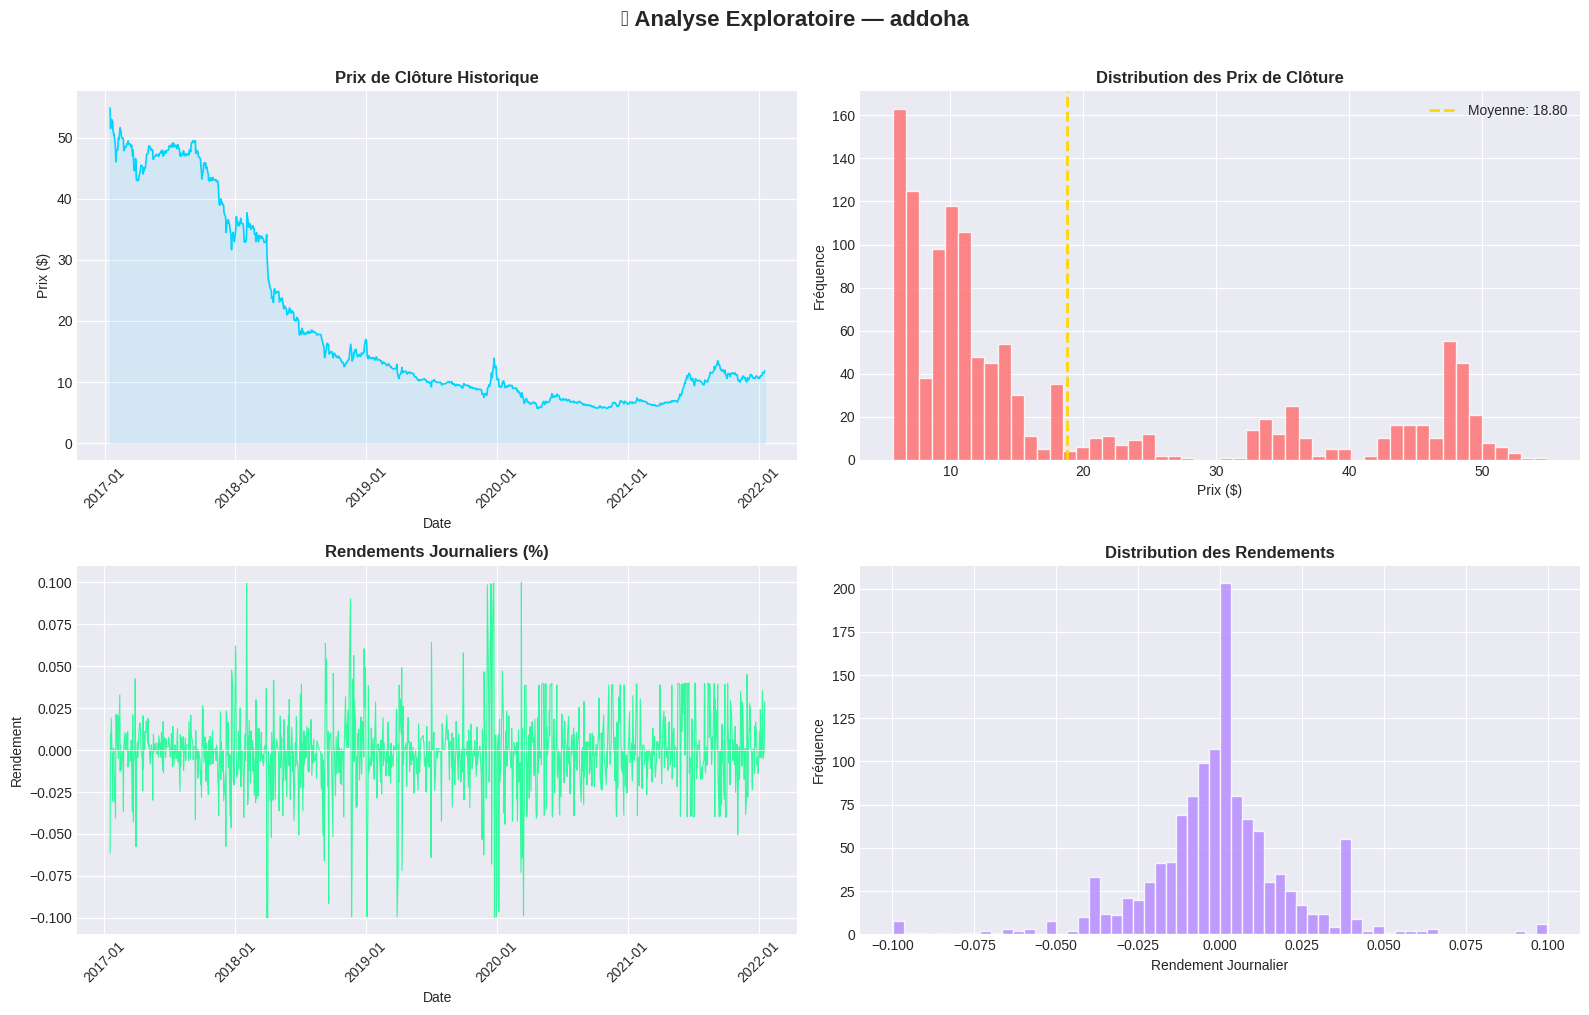

✅ Graphiques EDA générés !


In [ ]:
# ==============================================================================
# 🖼️ EDA VISUELLE — Distribution & Série Temporelle
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'📊 Analyse Exploratoire — {SELECTED_TICKER}', fontsize=16, fontweight='bold', y=1.01)

# ── Graphique 1 : Prix de clôture historique ──
axes[0, 0].plot(df_model['date'], df_model['close'], color='#00D4FF', linewidth=1.2)
axes[0, 0].fill_between(df_model['date'], df_model['close'], alpha=0.1, color='#00D4FF')
axes[0, 0].set_title('Prix de Clôture Historique', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Prix ($)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[0, 0].xaxis.get_majorticklabels(), rotation=45)

# ── Graphique 2 : Distribution des prix ──
axes[0, 1].hist(df_model['close'].dropna(), bins=50, color='#FF6B6B', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(df_model['close'].mean(), color='gold', linestyle='--', linewidth=2, label=f'Moyenne: {df_model["close"].mean():.2f}')
axes[0, 1].set_title('Distribution des Prix de Clôture', fontweight='bold')
axes[0, 1].set_xlabel('Prix ($)')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].legend()

# ── Graphique 3 : Rendements journaliers ──
returns = df_model['close'].pct_change().dropna()
axes[1, 0].plot(df_model['date'].iloc[1:], returns, color='#00FF88', linewidth=0.8, alpha=0.8)
axes[1, 0].axhline(0, color='white', linestyle='-', linewidth=0.5)
axes[1, 0].set_title('Rendements Journaliers (%)', fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Rendement')
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(axes[1, 0].xaxis.get_majorticklabels(), rotation=45)

# ── Graphique 4 : Volume (si disponible) ──
if 'volume' in df_model.columns and df_model['volume'].notna().any():
    axes[1, 1].bar(df_model['date'], df_model['volume'], color='#FFD700', alpha=0.6, width=1)
    axes[1, 1].set_title('Volume des Échanges', fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Volume')
    axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)
else:
    # Distribution des rendements si pas de volume
    axes[1, 1].hist(returns, bins=60, color='#B388FF', edgecolor='white', alpha=0.8)
    axes[1, 1].set_title('Distribution des Rendements', fontweight='bold')
    axes[1, 1].set_xlabel('Rendement Journalier')
    axes[1, 1].set_ylabel('Fréquence')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphiques EDA générés !')

## 🔧 ÉTAPE 4 — Feature Engineering Avancé

> **Objectif :** Créer des indicateurs techniques qui capturent la tendance, la momentum, la volatilité et les patterns cycliques pour enrichir le modèle.

In [ ]:
# ==============================================================================
# 🔧 FEATURE ENGINEERING — Indicateurs Techniques
# ==============================================================================

def compute_rsi(series, period=14):
    """
    Calcule le Relative Strength Index (RSI).
    RSI > 70 → Surachat (signal de vente)
    RSI < 30 → Survente (signal d'achat)
    """
    delta = series.diff()
    gain  = delta.where(delta > 0, 0.0)
    loss  = -delta.where(delta < 0, 0.0)
    avg_gain = gain.ewm(com=period - 1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period - 1, min_periods=period).mean()
    rs  = avg_gain / (avg_loss + 1e-10)
    rsi = 100 - (100 / (1 + rs))
    return rsi


def compute_bollinger_bands(series, window=20, num_std=2):
    """
    Calcule les Bandes de Bollinger.
    Mesure de la volatilité relative : bandes larges = forte volatilité.
    """
    sma   = series.rolling(window=window).mean()
    std   = series.rolling(window=window).std()
    upper = sma + (std * num_std)
    lower = sma - (std * num_std)
    bb_width = (upper - lower) / (sma + 1e-10)  # Largeur normalisée
    bb_pct   = (series - lower) / (upper - lower + 1e-10)  # Position dans la bande
    return upper, lower, bb_width, bb_pct


def add_features(df_input):
    """
    Pipeline complet de feature engineering.
    Retourne le dataframe enrichi avec tous les indicateurs.
    """
    df_feat = df_input.copy().sort_values('date').reset_index(drop=True)
    close   = df_feat['close']

    # ── 1. RENDEMENTS ──────────────────────────────────────────────
    df_feat['log_return']    = np.log(close / close.shift(1))
    df_feat['pct_return_1d'] = close.pct_change(1)
    df_feat['pct_return_3d'] = close.pct_change(3)
    df_feat['pct_return_5d'] = close.pct_change(5)

    # ── 2. MOYENNES MOBILES (Tendance) ─────────────────────────────
    for w in [5, 10, 20, 50]:
        df_feat[f'sma_{w}']   = close.rolling(window=w).mean()
        df_feat[f'ema_{w}']   = close.ewm(span=w, adjust=False).mean()
        df_feat[f'price_sma_{w}_ratio'] = close / (df_feat[f'sma_{w}'] + 1e-10)

    # ── 3. CROISEMENTS DE MOYENNES MOBILES ─────────────────────────
    df_feat['sma_20_50_cross'] = df_feat['sma_20'] - df_feat['sma_50']
    df_feat['ema_5_20_cross']  = df_feat['ema_5']  - df_feat['ema_20']

    # ── 4. RSI ─────────────────────────────────────────────────────
    df_feat['rsi_14']  = compute_rsi(close, period=14)
    df_feat['rsi_7']   = compute_rsi(close, period=7)

    # ── 5. BANDES DE BOLLINGER ─────────────────────────────────────
    bb_upper, bb_lower, bb_width, bb_pct = compute_bollinger_bands(close)
    df_feat['bb_upper'] = bb_upper
    df_feat['bb_lower'] = bb_lower
    df_feat['bb_width'] = bb_width
    df_feat['bb_pct']   = bb_pct

    # ── 6. VOLATILITÉ ──────────────────────────────────────────────
    df_feat['volatility_5d']  = df_feat['log_return'].rolling(5).std() * np.sqrt(252)
    df_feat['volatility_20d'] = df_feat['log_return'].rolling(20).std() * np.sqrt(252)

    # ── 7. MOMENTUM ────────────────────────────────────────────────
    df_feat['momentum_5d']  = close - close.shift(5)
    df_feat['momentum_10d'] = close - close.shift(10)
    df_feat['macd']         = df_feat['ema_5'] - df_feat['ema_20']
    df_feat['macd_signal']  = df_feat['macd'].ewm(span=9, adjust=False).mean()
    df_feat['macd_hist']    = df_feat['macd'] - df_feat['macd_signal']

    # ── 8. HIGH/LOW si disponibles ─────────────────────────────────
    if 'high' in df_feat.columns and 'low' in df_feat.columns:
        df_feat['hl_range']       = df_feat['high'] - df_feat['low']
        df_feat['hl_range_pct']   = df_feat['hl_range'] / (close + 1e-10)
        df_feat['high_20d']       = df_feat['high'].rolling(20).max()
        df_feat['low_20d']        = df_feat['low'].rolling(20).min()
        df_feat['distance_high']  = (close - df_feat['high_20d']) / (df_feat['high_20d'] + 1e-10)
        df_feat['distance_low']   = (close - df_feat['low_20d']) / (df_feat['low_20d'] + 1e-10)

    # ── 9. FEATURES CALENDAIRES ───────────────────────────────────
    df_feat['day_of_week']  = df_feat['date'].dt.dayofweek
    df_feat['day_of_month'] = df_feat['date'].dt.day
    df_feat['month']        = df_feat['date'].dt.month
    df_feat['quarter']      = df_feat['date'].dt.quarter
    df_feat['is_month_end'] = df_feat['date'].dt.is_month_end.astype(int)
    df_feat['is_quarter_end'] = df_feat['date'].dt.is_quarter_end.astype(int)

    # ── 10. VARIABLES LAGS (retards) ──────────────────────────────
    # Capture les patterns auto-régressifs (clé pour les séries temporelles)
    for lag in [1, 2, 3, 5, 7, 10, 14]:
        df_feat[f'lag_{lag}']        = close.shift(lag)
        df_feat[f'lag_return_{lag}'] = df_feat['log_return'].shift(lag)

    # ── 11. STATISTIQUES ROULANTES SUR LES LAGS ───────────────────
    for w in [5, 10, 20]:
        df_feat[f'rolling_mean_{w}'] = close.rolling(w).mean()
        df_feat[f'rolling_std_{w}']  = close.rolling(w).std()
        df_feat[f'rolling_min_{w}']  = close.rolling(w).min()
        df_feat[f'rolling_max_{w}']  = close.rolling(w).max()
        df_feat[f'rolling_skew_{w}'] = close.rolling(w).skew()

    return df_feat


# ── Application du Feature Engineering ──
print('⚙️ Calcul des indicateurs techniques...')
df_feat = add_features(df_model)

# Suppression des lignes avec trop de NaN (dues aux fenêtres roulantes)
df_feat = df_feat.dropna(thresh=int(df_feat.shape[1] * 0.6)).reset_index(drop=True)

print(f'✅ Feature Engineering terminé !')
print(f'   → Nombre de features créées : {df_feat.shape[1] - 2}')  # -2 pour date et close
print(f'   → Observations restantes    : {len(df_feat):,}')
print(f'\n📋 Aperçu des nouvelles colonnes :')
new_cols = [c for c in df_feat.columns if c not in df_model.columns]
print('   ' + ', '.join(new_cols[:15]) + '...')

⚙️ Calcul des indicateurs techniques...
✅ Feature Engineering terminé !
   → Nombre de features créées : 67
   → Observations restantes    : 1,236

📋 Aperçu des nouvelles colonnes :
   log_return, pct_return_1d, pct_return_3d, pct_return_5d, sma_5, ema_5, price_sma_5_ratio, sma_10, ema_10, price_sma_10_ratio, sma_20, ema_20, price_sma_20_ratio, sma_50, ema_50...


In [ ]:
# ==============================================================================
# 📊 VISUALISATION DES INDICATEURS TECHNIQUES
# ==============================================================================

# Utilisation de Plotly pour l'interactivité dans Colab
plot_df = df_feat.tail(252).copy()  # Derniers 12 mois environ

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=[
        f'Prix & Moyennes Mobiles — {SELECTED_TICKER}',
        'Bandes de Bollinger',
        'RSI (14 périodes)',
        'MACD'
    ],
    row_heights=[0.4, 0.2, 0.2, 0.2]
)

# ── Panel 1 : Prix + SMA ──
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['close'],
                          name='Close', line=dict(color='#00D4FF', width=1.5)), row=1, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['sma_20'],
                          name='SMA 20', line=dict(color='#FFD700', width=1, dash='dot')), row=1, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['sma_50'],
                          name='SMA 50', line=dict(color='#FF6B6B', width=1, dash='dot')), row=1, col=1)

# ── Panel 2 : Bollinger Bands ──
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['close'],
                          name='Close (BB)', line=dict(color='#00D4FF', width=1), showlegend=False), row=2, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['bb_upper'],
                          name='BB Upper', line=dict(color='rgba(255,107,107,0.7)', width=1),
                          fill=None), row=2, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['bb_lower'],
                          name='BB Lower', line=dict(color='rgba(255,107,107,0.7)', width=1),
                          fill='tonexty', fillcolor='rgba(255,107,107,0.1)'), row=2, col=1)

# ── Panel 3 : RSI ──
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['rsi_14'],
                          name='RSI 14', line=dict(color='#B388FF', width=1.5)), row=3, col=1)
fig.add_hline(y=70, line_dash='dash', line_color='red', row=3, col=1)
fig.add_hline(y=30, line_dash='dash', line_color='green', row=3, col=1)

# ── Panel 4 : MACD ──
colors_macd = ['green' if v >= 0 else 'red' for v in plot_df['macd_hist'].fillna(0)]
fig.add_trace(go.Bar(x=plot_df['date'], y=plot_df['macd_hist'],
                      name='MACD Hist', marker_color=colors_macd, opacity=0.7), row=4, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['macd'],
                          name='MACD', line=dict(color='#00FF88', width=1)), row=4, col=1)
fig.add_trace(go.Scatter(x=plot_df['date'], y=plot_df['macd_signal'],
                          name='Signal', line=dict(color='#FF6B6B', width=1, dash='dot')), row=4, col=1)

fig.update_layout(
    height=900,
    template='plotly_dark',
    title_text=f'📊 Analyse Technique Complète — {SELECTED_TICKER}',
    title_font_size=16,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=40, t=80, b=40)
)
fig.show()
print('✅ Graphique technique interactif généré !')

✅ Graphique technique interactif généré !


## 🤖 ÉTAPE 5 — Entraînement du Modèle XGBoost

> **Stratégie :** Utilisation d'un `TimeSeriesSplit` pour respecter la causalité temporelle (pas de data leakage), avec une pondération exponentielle des données récentes.

In [ ]:
# ==============================================================================
# 🎯 PRÉPARATION DU JEU DE DONNÉES POUR L'ENTRAÎNEMENT
# ==============================================================================

TARGET_HORIZON = 1  # Prédiction à J+1 (horizon principal)

# ── Définition de la cible (target) ──
# On prédit le prix de clôture du lendemain
df_feat['target'] = df_feat['close'].shift(-TARGET_HORIZON)

# ── Sélection des features (exclusion des colonnes non-informatives) ──
EXCLUDE_COLS = ['date', 'target', 'close', 'open', 'high', 'low', 'volume',
                'bb_upper', 'bb_lower', 'ticker'] if 'ticker' in df_feat.columns else \
               ['date', 'target', 'close', 'open', 'high', 'low', 'volume',
                'bb_upper', 'bb_lower']

FEATURE_COLS = [c for c in df_feat.columns if c not in EXCLUDE_COLS
                and df_feat[c].dtype in [np.float64, np.int64, float, int]]

# Suppression des lignes sans target valide
df_clean = df_feat[FEATURE_COLS + ['date', 'close', 'target']].dropna().copy()

X = df_clean[FEATURE_COLS].values
y = df_clean['target'].values
dates = df_clean['date'].values

print(f'🎯 Configuration de l\'entraînement :')
print(f'   → Features            : {X.shape[1]}')
print(f'   → Observations totales: {X.shape[0]:,}')
print(f'   → Target              : Prix de clôture à J+{TARGET_HORIZON}')

# ── Split Temporel (80% train / 20% test) ──
TRAIN_SIZE = 0.80
split_idx  = int(len(X) * TRAIN_SIZE)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
dates_test      = dates[split_idx:]

print(f'\n📊 Split Temporel :')
print(f'   → Train : {X_train.shape[0]:,} obs ({pd.Timestamp(dates[0]).date()} → {pd.Timestamp(dates[split_idx-1]).date()})')
print(f'   → Test  : {X_test.shape[0]:,} obs  ({pd.Timestamp(dates[split_idx]).date()} → {pd.Timestamp(dates[-1]).date()})')

🎯 Configuration de l'entraînement :
   → Features            : 60
   → Observations totales: 1,194
   → Target              : Prix de clôture à J+1

📊 Split Temporel :
   → Train : 955 obs (2017-03-24 → 2021-02-01)
   → Test  : 239 obs  (2021-02-02 → 2022-01-17)


⚖️ Distribution des poids temporels :
   → Poids 1er quartile (données anciennes) : 0.000265
   → Poids 2e quartile                     : 0.000541
   → Poids 3e quartile                     : 0.001109
   → Poids 4e quartile (données récentes)  : 0.002271
   → Ratio Récent/Ancien                   : 17.5x


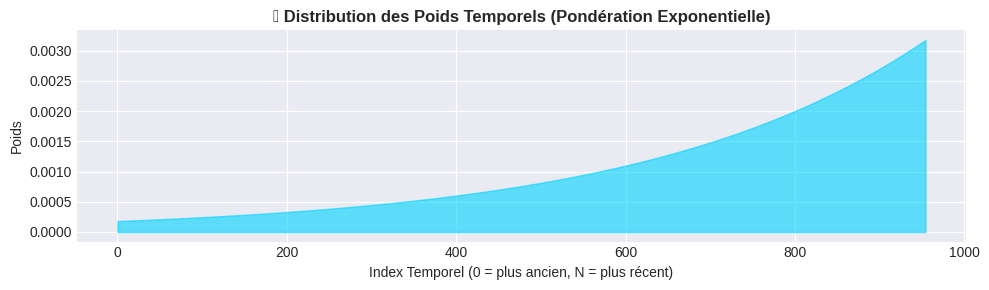

In [ ]:
# ==============================================================================
# ⚖️ PONDÉRATION TEMPORELLE EXPONENTIELLE
# ==============================================================================

def compute_temporal_weights(n_samples, decay_factor=0.002):
    """
    Calcule des poids exponentiels décroissants dans le temps.

    Logique : les observations récentes ont plus d'influence sur l'apprentissage.
    Formule : w_i = exp(decay * i) / sum(exp(decay * j))

    - decay_factor faible  → pondération quasi-uniforme
    - decay_factor élevé   → focus fort sur les données récentes
    """
    indices = np.arange(n_samples)
    weights = np.exp(decay_factor * indices)
    weights = weights / weights.sum()  # Normalisation
    return weights


# Calcul des poids pour le set d'entraînement
sample_weights = compute_temporal_weights(len(X_train), decay_factor=0.003)

# Normalisation pour XGBoost (scale 0-1)
sample_weights_norm = sample_weights / sample_weights.max()

print('⚖️ Distribution des poids temporels :')
n = len(sample_weights)
print(f'   → Poids 1er quartile (données anciennes) : {sample_weights[:n//4].mean():.6f}')
print(f'   → Poids 2e quartile                     : {sample_weights[n//4:n//2].mean():.6f}')
print(f'   → Poids 3e quartile                     : {sample_weights[n//2:3*n//4].mean():.6f}')
print(f'   → Poids 4e quartile (données récentes)  : {sample_weights[3*n//4:].mean():.6f}')
print(f'   → Ratio Récent/Ancien                   : {sample_weights[-1]/sample_weights[0]:.1f}x')

# Visualisation de la distribution des poids
fig_w, ax_w = plt.subplots(figsize=(10, 3))
ax_w.fill_between(range(n), sample_weights, color='#00D4FF', alpha=0.6)
ax_w.set_title('📊 Distribution des Poids Temporels (Pondération Exponentielle)', fontweight='bold')
ax_w.set_xlabel('Index Temporel (0 = plus ancien, N = plus récent)')
ax_w.set_ylabel('Poids')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 🤖 ENTRAÎNEMENT DU MODÈLE XGBOOST
# ==============================================================================

print('🚀 Entraînement du modèle XGBoost...')
print('─' * 50)

# ── Hyperparamètres optimisés pour les séries temporelles financières ──
xgb_params = {
    'n_estimators'       : 800,          # Nombre d'arbres
    'max_depth'          : 6,            # Profondeur max (évite surapprentissage)
    'learning_rate'      : 0.03,         # Faible pour meilleure généralisation
    'subsample'          : 0.8,          # 80% des données par arbre (régularisation)
    'colsample_bytree'   : 0.7,          # 70% des features par arbre
    'min_child_weight'   : 3,            # Régularisation L2 sur les feuilles
    'reg_alpha'          : 0.1,          # Régularisation L1 (Lasso)
    'reg_lambda'         : 1.0,          # Régularisation L2 (Ridge)
    'gamma'              : 0.1,          # Réduction minimale de perte pour split
    'random_state'       : RANDOM_STATE,
    'n_jobs'             : -1,           # Utilise tous les cœurs disponibles
    'tree_method'        : 'hist',       # Rapide pour grands datasets
    'eval_metric'        : 'rmse'
}

model_xgb = XGBRegressor(**xgb_params)

# Entraînement avec poids temporels et early stopping
model_xgb.fit(
    X_train, y_train,
    sample_weight = sample_weights_norm,
    eval_set      = [(X_test, y_test)],
    verbose       = 100
)

print('\n✅ Modèle entraîné avec succès !')

🚀 Entraînement du modèle XGBoost...
──────────────────────────────────────────────────
[0]	validation_0-rmse:2.68293
[100]	validation_0-rmse:0.29259
[200]	validation_0-rmse:0.27193
[300]	validation_0-rmse:0.27351
[400]	validation_0-rmse:0.27361
[500]	validation_0-rmse:0.27370
[600]	validation_0-rmse:0.27371
[700]	validation_0-rmse:0.27377
[799]	validation_0-rmse:0.27375

✅ Modèle entraîné avec succès !


📊 MÉTRIQUES DE PERFORMANCE — SET DE TEST
  RMSE                  : 0.2737
  MAE                   : 0.2043
  R²                    : 0.9838 (98.4% de variance expliquée)
  MAPE                  : 2.05%
  Précision Directionnelle : 52.5%

🔀 Cross-Validation Temporelle (5 folds) :
  RMSE moyen : 4.6743 ± 5.0053


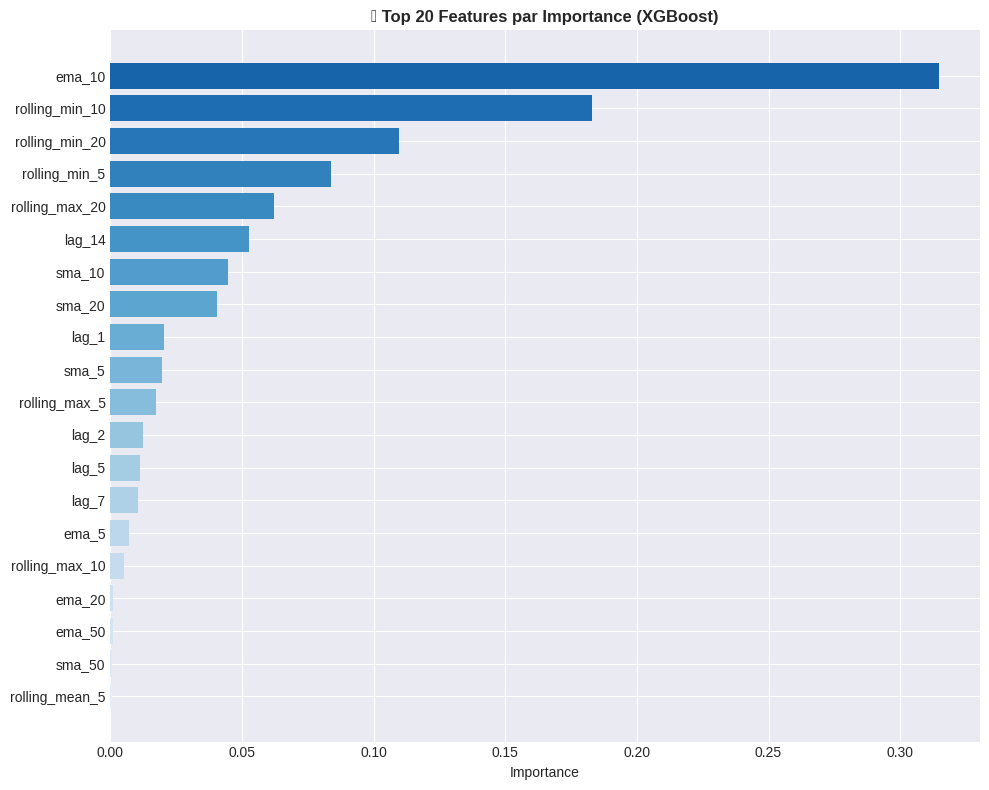


✅ Évaluation complète !


In [ ]:
# ==============================================================================
# 📏 ÉVALUATION DU MODÈLE SUR LE JEU DE TEST
# ==============================================================================

y_pred_test = model_xgb.predict(X_test)

# ── Métriques de performance ──
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae  = mean_absolute_error(y_test, y_pred_test)
r2   = r2_score(y_test, y_pred_test)

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred_test) / (np.abs(y_test) + 1e-10))) * 100

# Directional Accuracy (précision sur la direction)
actual_direction   = np.sign(np.diff(y_test))
pred_direction     = np.sign(np.diff(y_pred_test))
dir_accuracy       = np.mean(actual_direction == pred_direction) * 100

print('=' * 50)
print('📊 MÉTRIQUES DE PERFORMANCE — SET DE TEST')
print('=' * 50)
print(f'  RMSE                  : {rmse:.4f}')
print(f'  MAE                   : {mae:.4f}')
print(f'  R²                    : {r2:.4f} ({r2*100:.1f}% de variance expliquée)')
print(f'  MAPE                  : {mape:.2f}%')
print(f'  Précision Directionnelle : {dir_accuracy:.1f}%')

# ── Cross-validation temporelle ──
tscv   = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model_xgb, X_train, y_train, cv=tscv,
                          scoring='neg_root_mean_squared_error')
print(f'\n🔀 Cross-Validation Temporelle (5 folds) :')
print(f'  RMSE moyen : {-scores.mean():.4f} ± {scores.std():.4f}')

# ── Importance des features ──
importance_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig_imp, ax_imp = plt.subplots(figsize=(10, 8))
colors_imp = plt.cm.Blues_r(np.linspace(0.2, 0.9, len(importance_df)))
ax_imp.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
             color=colors_imp[::-1])
ax_imp.set_title('🔍 Top 20 Features par Importance (XGBoost)', fontweight='bold')
ax_imp.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Évaluation complète !')

## 🔮 ÉTAPE 6 — Prédiction 15 Jours avec Logique de Confiance

> **Mécanisme :** Prédiction itérative en boucle. Chaque prédiction J+n est réinjectée comme feature pour calculer J+(n+1). L'erreur s'accumule, créant naturellement des intervalles de confiance croissants.

In [ ]:
# ==============================================================================
# 🔮 PRÉDICTION ITÉRATIVE SUR 15 JOURS
# ==============================================================================

FORECAST_DAYS    = 15
N_SIMULATIONS    = 200   # Monte Carlo pour intervalles de confiance
NOISE_SCALE_BASE = 0.005  # Bruit de base (0.5% du prix)


def get_next_business_day(date):
    """Retourne le prochain jour ouvré (exclut week-ends)."""
    next_day = date + timedelta(days=1)
    while next_day.weekday() >= 5:  # 5=Sat, 6=Sun
        next_day += timedelta(days=1)
    return next_day


def predict_next_15_days(model, df_features, feature_cols, n_days=15,
                          n_simulations=200, noise_scale=0.005):
    """
    Prédiction itérative sur n_days jours avec intervalles de confiance Monte Carlo.

    Logique d'affinage :
    - J+1 : Faible incertitude (données réelles récentes disponibles)
    - J+n : Erreur cumulée des prédictions précédentes → variance croissante
    - Modélisation : bruit gaussien proportionnel à sqrt(n) × volatilité historique

    Parameters:
        noise_scale : proportion du prix utilisée comme écart-type de base du bruit
    """
    # Données récentes (dernière observation connue)
    last_known = df_features.iloc[-1].copy()
    last_date  = pd.Timestamp(last_known['date'])
    last_close = last_known['close']

    # Volatilité historique récente (pour calibrer le bruit)
    recent_vol   = df_features['log_return'].tail(30).std()
    recent_close = df_features['close'].tail(50).values

    point_predictions = []
    lower_bounds      = []
    upper_bounds      = []
    forecast_dates    = []
    confidence_scores = []
    rmse_horizons     = []

    # ── Simulation Monte Carlo ──────────────────────────────────────────────
    all_sim_paths = np.zeros((n_simulations, n_days))

    for sim in range(n_simulations):
        # Initialisation avec les données réelles
        sim_df     = df_features.copy()
        sim_prices = list(recent_close)

        for day in range(n_days):
            # Features calculées sur données simulées
            sim_close_series = pd.Series(sim_prices)

            # Construction du vecteur de features pour cette date
            feat_row = {}
            for col in feature_cols:
                if col in last_known.index:
                    feat_row[col] = last_known[col]

            # Mise à jour des features dynamiques (lags, MA)
            n_sim = len(sim_prices)
            if 'lag_1' in feat_row:
                feat_row['lag_1']        = sim_prices[-1] if n_sim >= 1 else feat_row.get('lag_1', 0)
                feat_row['lag_2']        = sim_prices[-2] if n_sim >= 2 else feat_row.get('lag_2', 0)
                feat_row['lag_3']        = sim_prices[-3] if n_sim >= 3 else feat_row.get('lag_3', 0)
                feat_row['lag_5']        = sim_prices[-5] if n_sim >= 5 else feat_row.get('lag_5', 0)
                feat_row['lag_7']        = sim_prices[-7] if n_sim >= 7 else feat_row.get('lag_7', 0)
            if 'sma_20' in feat_row and n_sim >= 20:
                feat_row['sma_20']       = np.mean(sim_prices[-20:])
                feat_row['rolling_mean_20'] = feat_row['sma_20']
                feat_row['rolling_std_20']  = np.std(sim_prices[-20:])
            if 'sma_5' in feat_row and n_sim >= 5:
                feat_row['sma_5']        = np.mean(sim_prices[-5:])
                feat_row['rolling_mean_5'] = feat_row['sma_5']

            # Prédiction du modèle
            X_pred   = np.array([[feat_row.get(col, 0) for col in feature_cols]])
            pred_val = model.predict(X_pred)[0]

            # ── LOGIQUE DE BRUIT CROISSANT (affinage par proximité) ──
            # J+1 → bruit minimal | J+15 → bruit max sqrt(15) fois plus grand
            # Reflète l'accumulation d'incertitude sur l'horizon
            horizon_noise = noise_scale * pred_val * np.sqrt(day + 1) * recent_vol * 15
            noise = np.random.normal(0, max(horizon_noise, pred_val * 0.001))

            sim_prices.append(pred_val + (noise if sim > 0 else 0))
            all_sim_paths[sim, day] = pred_val + (noise if sim > 0 else 0)

    # ── Calcul des statistiques sur les simulations ─────────────────────────
    current_date = last_date

    for day in range(n_days):
        current_date   = get_next_business_day(current_date)
        sim_values     = all_sim_paths[:, day]
        point_pred     = np.median(sim_values)

        # Intervalles de confiance (percentiles)
        # Plus l'horizon est lointain, plus l'intervalle est large
        ci_level = 95 - (day * 2)  # 95% à J+1 → 69% à J+14 (dégradation graduelle)
        ci_level = max(ci_level, 50)
        alpha    = (100 - ci_level) / 2
        lb       = np.percentile(sim_values, alpha)
        ub       = np.percentile(sim_values, 100 - alpha)

        # Score de confiance inverse (100% à J+1, décroissant)
        conf_score = max(100 - (day * 5), 25)

        # RMSE simulé (augmentation en sqrt de l'horizon)
        sim_rmse = rmse * np.sqrt(day + 1)

        point_predictions.append(point_pred)
        lower_bounds.append(lb)
        upper_bounds.append(ub)
        forecast_dates.append(current_date)
        confidence_scores.append(conf_score)
        rmse_horizons.append(sim_rmse)

    return pd.DataFrame({
        'date'           : forecast_dates,
        'predicted'      : point_predictions,
        'lower_95'       : lower_bounds,
        'upper_95'       : upper_bounds,
        'confidence_pct' : confidence_scores,
        'horizon_rmse'   : rmse_horizons,
        'horizon_day'    : list(range(1, n_days + 1))
    })


# ── Exécution des prédictions ──
print(f'🔮 Calcul des prédictions pour {FORECAST_DAYS} jours ouvrés...')
print('   (Monte Carlo avec 200 simulations — peut prendre 10-20 secondes)')

forecast_df = predict_next_15_days(
    model_xgb, df_clean, FEATURE_COLS,
    n_days=FORECAST_DAYS, n_simulations=N_SIMULATIONS, noise_scale=NOISE_SCALE_BASE
)

print('\n✅ Prédictions calculées !')
print('\n📋 TABLEAU DES PRÉVISIONS 15 JOURS :')
print('─' * 75)

last_real_price = df_clean['close'].iloc[-1]
display_df = forecast_df[['date', 'horizon_day', 'predicted', 'lower_95', 'upper_95',
                            'confidence_pct', 'horizon_rmse']].copy()
display_df['date'] = display_df['date'].dt.strftime('%Y-%m-%d (%a)')
display_df['variation_%'] = ((display_df['predicted'] - last_real_price) / last_real_price * 100).round(2)
display_df.columns = ['Date', 'J+', 'Prédit ($)', 'Borne Inf ($)', 'Borne Sup ($)',
                        'Confiance (%)', 'RMSE Estimé', 'Variation (%)']
display_df = display_df.round(4)
display(display_df)

🔮 Calcul des prédictions pour 15 jours ouvrés...
   (Monte Carlo avec 200 simulations — peut prendre 10-20 secondes)

✅ Prédictions calculées !

📋 TABLEAU DES PRÉVISIONS 15 JOURS :
───────────────────────────────────────────────────────────────────────────


,Date,J+,Prédit ($),Borne Inf ($),Borne Sup ($),Confiance (%),RMSE Estimé,Variation (%)
0,2022-01-18 (Tue),1,11.7836,11.7585,11.8058,100,0.2737,2.3800
1,2022-01-19 (Wed),2,11.7806,11.7515,11.8159,95,0.3871,2.3500
2,2022-01-20 (Thu),3,11.7866,11.7553,11.8239,90,0.4741,2.4000
3,2022-01-21 (Fri),4,11.7913,11.7532,11.8258,85,0.5475,2.4400
4,2022-01-24 (Mon),5,11.7877,11.7507,11.8328,80,0.6121,2.4100
5,2022-01-25 (Tue),6,11.7894,11.7439,11.8376,75,0.6705,2.4300
6,2022-01-26 (Wed),7,11.7883,11.7434,11.8387,70,0.7243,2.4200
7,2022-01-27 (Thu),8,11.7884,11.7416,11.8376,65,0.7743,2.4200
8,2022-01-28 (Fri),9,11.7892,11.7461,11.8327,60,0.8212,2.4300
9,2022-01-31 (Mon),10,11.7953,11.7463,11.8456,55,0.8657,2.4800


## 📉 ÉTAPE 7 — Visualisations Finales

In [ ]:
# ==============================================================================
# 📈 GRAPHIQUE 1 : PRIX RÉELS VS PRÉDITS + PRÉVISIONS 15 JOURS
# ==============================================================================

# Données réelles (derniers 60 jours pour plus de lisibilité)
LOOKBACK_DAYS = 60
historical    = df_clean.tail(LOOKBACK_DAYS).copy()
hist_pred     = y_pred_test[-LOOKBACK_DAYS:] if len(y_pred_test) >= LOOKBACK_DAYS else y_pred_test
hist_dates_p  = pd.to_datetime(dates_test[-len(hist_pred):])

fig1 = go.Figure()

# ── Ligne : Prix réels historiques ──
fig1.add_trace(go.Scatter(
    x=pd.to_datetime(historical['date']), y=historical['close'],
    name='📊 Prix Réels', mode='lines',
    line=dict(color='#00D4FF', width=2),
    hovertemplate='Date: %{x|%Y-%m-%d}<br>Prix: $%{y:.2f}<extra></extra>'
))

# ── Ligne : Prix prédits (backtest) ──
fig1.add_trace(go.Scatter(
    x=hist_dates_p, y=hist_pred,
    name='🤖 Prédits (Backtest)', mode='lines',
    line=dict(color='#FFD700', width=1.5, dash='dot'),
    hovertemplate='Date: %{x|%Y-%m-%d}<br>Prédit: $%{y:.2f}<extra></extra>'
))

# ── Zone de confiance (prévisions) ──
fig1.add_trace(go.Scatter(
    x=pd.concat([forecast_df['date'], forecast_df['date'][::-1]]),
    y=pd.concat([forecast_df['upper_95'], forecast_df['lower_95'][::-1]]),
    fill='toself', fillcolor='rgba(255, 107, 107, 0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    name='Intervalle de Confiance',
    hoverinfo='skip'
))

# ── Ligne : Prévisions futures ──
fig1.add_trace(go.Scatter(
    x=forecast_df['date'], y=forecast_df['predicted'],
    name='🔮 Prévisions J+15', mode='lines+markers',
    line=dict(color='#FF6B6B', width=2.5),
    marker=dict(size=8, color=forecast_df['confidence_pct'],
                colorscale='RdYlGn', cmin=20, cmax=100,
                showscale=True,
                colorbar=dict(title='Confiance %', x=1.05, len=0.5)),
    hovertemplate='Date: %{x|%Y-%m-%d}<br>Prévu: $%{y:.2f}<br>Confiance: %{marker.color:.0f}%<extra></extra>'
))

# ── Ligne verticale : Frontière présent/futur ──
last_date_str = df_clean['date'].iloc[-1].isoformat() # Convert to ISO string
fig1.add_vline(
    x=last_date_str, line_dash='dash', line_color='white', line_width=1.5,
    annotation_text='Aujourd\'hui', # Removed annotation_position to avoid TypeError
    annotation_font_color='white'
)

fig1.update_layout(
    title=dict(
        text=f'📈 Prédiction de Prix — {SELECTED_TICKER} | XGBoost + Monte Carlo',
        font=dict(size=18)
    ),
    xaxis_title='Date',
    yaxis_title='Prix ($)',
    template='plotly_dark',
    height=550,
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='right', x=1),
    margin=dict(l=60, r=100, t=80, b=60)
)

fig1.show()
print('✅ Graphique 1 : Prédictions 15 jours avec intervalles de confiance !')

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
# ==============================================================================
# 📉 GRAPHIQUE 2 : DÉGRADATION DE LA PRÉCISION PAR HORIZON
# ==============================================================================

horizons        = forecast_df['horizon_day'].values
rmse_vals       = forecast_df['horizon_rmse'].values
confidence_vals = forecast_df['confidence_pct'].values
ci_width        = forecast_df['upper_95'] - forecast_df['lower_95']

fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        '📉 RMSE Estimé par Horizon de Prédiction',
        '🎯 Indice de Confiance (%) par Horizon',
        '📊 Largeur de l\'Intervalle de Confiance',
        '🔮 Synthèse : Précision vs Horizon'
    ],
    vertical_spacing=0.15,
    horizontal_spacing=0.12
)

# ── Panel 1 : RMSE par horizon ──
fig2.add_trace(go.Scatter(
    x=horizons, y=rmse_vals,
    mode='lines+markers',
    line=dict(color='#FF6B6B', width=2.5),
    marker=dict(size=10, color='#FF6B6B'),
    fill='tozeroy', fillcolor='rgba(255,107,107,0.15)',
    name='RMSE'
), row=1, col=1)

# Annotation à J+1 vs J+15
fig2.add_annotation(x=1, y=rmse_vals[0],
                     text=f'J+1: {rmse_vals[0]:.3f}',
                     showarrow=True, arrowhead=2, row=1, col=1,
                     font=dict(color='#00FF88'))
fig2.add_annotation(x=15, y=rmse_vals[-1],
                     text=f'J+15: {rmse_vals[-1]:.3f}',
                     showarrow=True, arrowhead=2, row=1, col=1,
                     font=dict(color='#FF6B6B'))

# ── Panel 2 : Score de confiance ──
bar_colors = [f'rgb({int(255*(1-c/100))}, {int(200*(c/100))}, {int(100*(c/100))})'
               for c in confidence_vals]
fig2.add_trace(go.Bar(
    x=[f'J+{h}' for h in horizons], y=confidence_vals,
    marker_color=bar_colors, name='Confiance %',
    text=[f'{c:.0f}%' for c in confidence_vals],
    textposition='outside'
), row=1, col=2)

# ── Panel 3 : Largeur de l'intervalle ──
fig2.add_trace(go.Bar(
    x=[f'J+{h}' for h in horizons], y=ci_width.values,
    marker=dict(
        color=ci_width.values,
        colorscale='Reds',
        showscale=False
    ),
    name='Largeur IC'
), row=2, col=1)

# ── Panel 4 : Dual axis - RMSE normalisé + Confiance ──
rmse_norm = (rmse_vals - rmse_vals.min()) / (rmse_vals.max() - rmse_vals.min() + 1e-10) * 100

fig2.add_trace(go.Scatter(
    x=horizons, y=rmse_norm,
    mode='lines+markers',
    name='Erreur Relative (%)',
    line=dict(color='#FF6B6B', width=2)
), row=2, col=2)

fig2.add_trace(go.Scatter(
    x=horizons, y=confidence_vals,
    mode='lines+markers',
    name='Confiance (%)',
    line=dict(color='#00FF88', width=2, dash='dot')
), row=2, col=2)

fig2.update_layout(
    template='plotly_dark',
    height=700,
    title=dict(
        text='📉 Analyse de la Dégradation de Précision par Horizon Temporel',
        font=dict(size=16)
    ),
    showlegend=False,
    margin=dict(l=60, r=40, t=100, b=60)
)

# Labels axes
fig2.update_xaxes(title_text='Horizon (Jours)', row=1, col=1)
fig2.update_yaxes(title_text='RMSE', row=1, col=1)
fig2.update_xaxes(title_text='Horizon', row=1, col=2)
fig2.update_yaxes(title_text='Confiance (%)', row=1, col=2, range=[0, 110])
fig2.update_xaxes(title_text='Horizon', row=2, col=1)
fig2.update_yaxes(title_text='Largeur ($)', row=2, col=1)
fig2.update_xaxes(title_text='Horizon (Jours)', row=2, col=2)
fig2.update_yaxes(title_text='Score (0-100)', row=2, col=2)

fig2.show()
print('✅ Graphique 2 : Analyse de dégradation de la précision par horizon !')

✅ Graphique 2 : Analyse de dégradation de la précision par horizon !


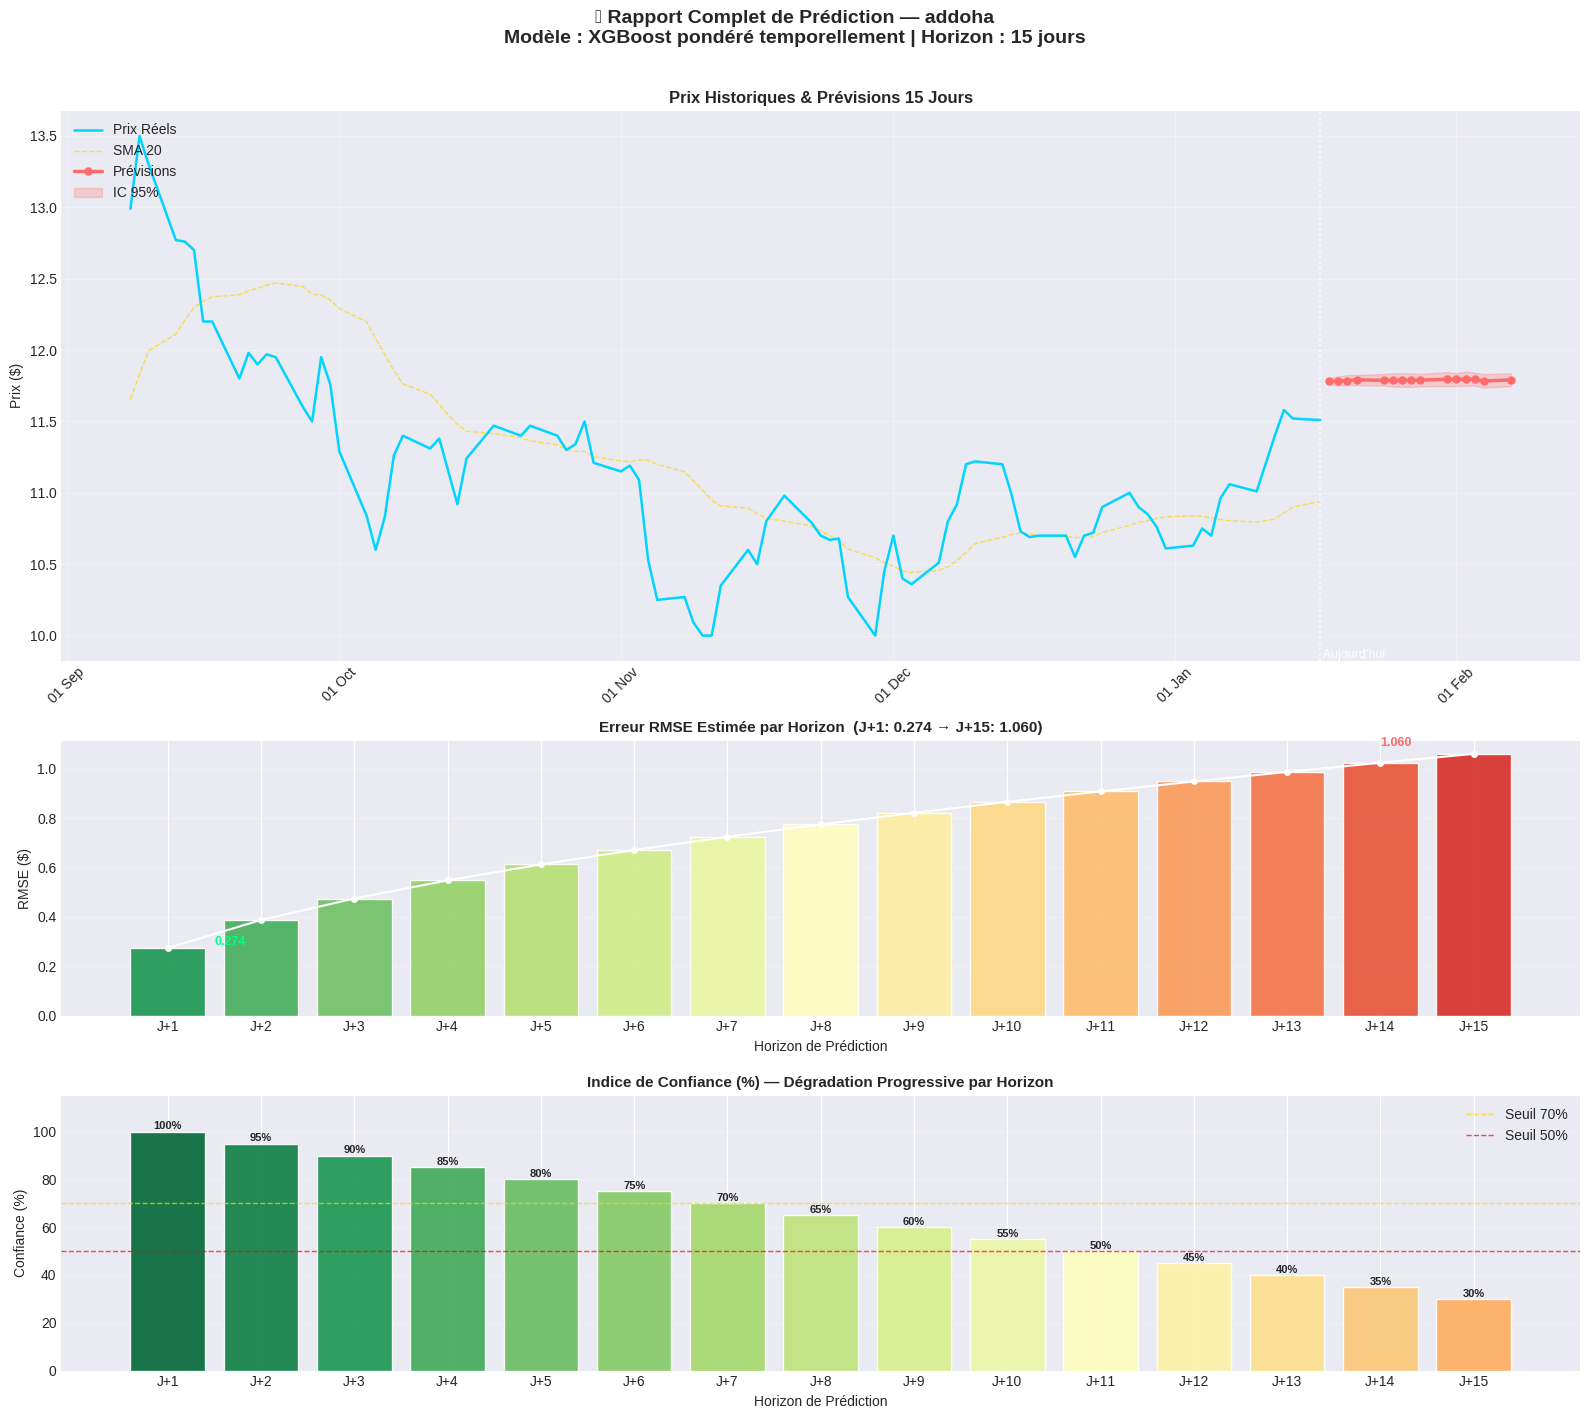

✅ Rapport final sauvegardé : rapport_prediction_final.png


In [ ]:
# ==============================================================================
# 📊 GRAPHIQUE 3 : RAPPORT FINAL COMPLET (Matplotlib)
# ==============================================================================

fig3, axes3 = plt.subplots(3, 1, figsize=(16, 14),
                             gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
fig3.suptitle(f'🔮 Rapport Complet de Prédiction — {SELECTED_TICKER}\n'
               f'Modèle : XGBoost pondéré temporellement | Horizon : {FORECAST_DAYS} jours',
               fontsize=14, fontweight='bold', y=1.01)

# ── Panel 1 : Prix complet + prévisions ──
ax1 = axes3[0]
hist_n = min(90, len(df_clean))
hist_slice = df_clean.tail(hist_n)

ax1.plot(pd.to_datetime(hist_slice['date']), hist_slice['close'],
          color='#00D4FF', linewidth=1.8, label='Prix Réels', zorder=3)

# SMA 20 sur la période historique
if 'sma_20' in hist_slice.columns:
    ax1.plot(pd.to_datetime(hist_slice['date']), hist_slice['sma_20'],
              color='#FFD700', linewidth=1, linestyle='--', label='SMA 20', alpha=0.7)

# Prévisions
forecast_dates_plt = pd.to_datetime(forecast_df['date'])
ax1.plot(forecast_dates_plt, forecast_df['predicted'],
          color='#FF6B6B', linewidth=2.5, linestyle='-',
          marker='o', markersize=5, label='Prévisions', zorder=4)

# Zone de confiance
ax1.fill_between(forecast_dates_plt, forecast_df['lower_95'], forecast_df['upper_95'],
                  alpha=0.25, color='#FF6B6B', label='IC 95%')

# Ligne verticale
ax1.axvline(pd.to_datetime(df_clean['date'].iloc[-1]),
             color='white', linestyle=':', linewidth=1.5, alpha=0.8)
ax1.text(pd.to_datetime(df_clean['date'].iloc[-1]), ax1.get_ylim()[0] if ax1.get_ylim()[0] != 0 else hist_slice['close'].min(),
          ' Aujourd\'hui', fontsize=9, color='white', va='bottom')

ax1.set_title('Prix Historiques & Prévisions 15 Jours', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prix ($)')
ax1.legend(loc='upper left', framealpha=0.8)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# ── Panel 2 : RMSE par horizon ──
ax2 = axes3[1]
bar_colors_r = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(horizons)))
bars = ax2.bar([f'J+{h}' for h in horizons], rmse_vals, color=bar_colors_r, edgecolor='white', alpha=0.9)
ax2.plot([f'J+{h}' for h in horizons], rmse_vals,
          color='white', linewidth=1.5, marker='o', markersize=4, zorder=5)

# Annotations sur les barres J+1 et J+15
ax2.annotate(f'{rmse_vals[0]:.3f}', xy=(0, rmse_vals[0]), xytext=(0.5, rmse_vals[0]*1.05),
              fontsize=9, color='#00FF88', fontweight='bold')
ax2.annotate(f'{rmse_vals[-1]:.3f}', xy=(14, rmse_vals[-1]), xytext=(13, rmse_vals[-1]*1.03),
              fontsize=9, color='#FF6B6B', fontweight='bold')

ax2.set_title(f'Erreur RMSE Estimée par Horizon  (J+1: {rmse_vals[0]:.3f} → J+15: {rmse_vals[-1]:.3f})',
               fontsize=11, fontweight='bold')
ax2.set_ylabel('RMSE ($)')
ax2.set_xlabel('Horizon de Prédiction')
ax2.grid(True, alpha=0.3, axis='y')

# ── Panel 3 : Score de confiance ──
ax3 = axes3[2]
conf_colors = plt.cm.RdYlGn(confidence_vals / 100)
ax3.bar([f'J+{h}' for h in horizons], confidence_vals, color=conf_colors, edgecolor='white', alpha=0.9)
ax3.axhline(70, color='gold', linestyle='--', linewidth=1, alpha=0.7, label='Seuil 70%')
ax3.axhline(50, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Seuil 50%')

for i, (h, cv) in enumerate(zip(horizons, confidence_vals)):
    ax3.text(i, cv + 1, f'{cv:.0f}%', ha='center', fontsize=8, fontweight='bold')

ax3.set_title('Indice de Confiance (%) — Dégradation Progressive par Horizon',
               fontsize=11, fontweight='bold')
ax3.set_ylabel('Confiance (%)')
ax3.set_xlabel('Horizon de Prédiction')
ax3.set_ylim(0, 115)
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('rapport_prediction_final.png', dpi=150, bbox_inches='tight',
             facecolor='#1a1a2e')
plt.show()
print('✅ Rapport final sauvegardé : rapport_prediction_final.png')

In [ ]:
# ==============================================================================
# 📋 RÉSUMÉ FINAL & EXPORT
# ==============================================================================

print('=' * 65)
print('🎯 RÉSUMÉ EXÉCUTIF DU MODÈLE')
print('=' * 65)
print(f'\n  📌 Ticker analysé       : {SELECTED_TICKER}')
print(f'  📅 Dernière date réelle : {df_clean["date"].iloc[-1].strftime("%Y-%m-%d")}')
print(f'  💰 Dernier prix connu   : ${df_clean["close"].iloc[-1]:.4f}')
print(f'  🔮 Prix prévu J+1        : ${forecast_df["predicted"].iloc[0]:.4f}')
print(f'  🔮 Prix prévu J+5        : ${forecast_df["predicted"].iloc[4]:.4f}')
print(f'  🔮 Prix prévu J+15       : ${forecast_df["predicted"].iloc[-1]:.4f}')

var_j15 = (forecast_df['predicted'].iloc[-1] - df_clean['close'].iloc[-1]) / df_clean['close'].iloc[-1] * 100
trend   = '🟢 Haussière' if var_j15 > 0 else '🔴 Baissière'
print(f'\n  📊 Variation estimée J+15: {var_j15:+.2f}%')
print(f'  📈 Tendance prévue        : {trend}')

print(f'\n  📏 Performance du Modèle (set de test) :')
print(f'     RMSE  = {rmse:.4f}')
print(f'     MAE   = {mae:.4f}')
print(f'     R²    = {r2:.4f}')
print(f'     MAPE  = {mape:.2f}%')
print(f'     Dir.Acc = {dir_accuracy:.1f}%')

print(f'\n  ⚠️  AVERTISSEMENT : Ce modèle est à des fins éducatives')
print(f'      uniquement. Il ne constitue pas un conseil financier.')
print('=' * 65)

# ── Export CSV des prévisions ──
forecast_df.to_csv('predictions_15_jours.csv', index=False)
print('\n📁 Fichiers générés :')
print('   → predictions_15_jours.csv')
print('   → rapport_prediction_final.png')
print('   → feature_importance.png')
print('   → eda_plots.png')
print('\n✅ Pipeline complet terminé avec succès !')

🎯 RÉSUMÉ EXÉCUTIF DU MODÈLE

  📌 Ticker analysé       : addoha
  📅 Dernière date réelle : 2022-01-17
  💰 Dernier prix connu   : $11.5100
  🔮 Prix prévu J+1        : $11.7836
  🔮 Prix prévu J+5        : $11.7877
  🔮 Prix prévu J+15       : $11.7912

  📊 Variation estimée J+15: +2.44%
  📈 Tendance prévue        : 🟢 Haussière

  📏 Performance du Modèle (set de test) :
     RMSE  = 0.2737
     MAE   = 0.2043
     R²    = 0.9838
     MAPE  = 2.05%
     Dir.Acc = 52.5%

  ⚠️  AVERTISSEMENT : Ce modèle est à des fins éducatives
      uniquement. Il ne constitue pas un conseil financier.

📁 Fichiers générés :
   → predictions_15_jours.csv
   → rapport_prediction_final.png
   → feature_importance.png
   → eda_plots.png

✅ Pipeline complet terminé avec succès !


---

## 📖 Notes Méthodologiques

### 🤖 Choix du Modèle : XGBoost
XGBoost (eXtreme Gradient Boosting) est particulièrement adapté aux séries temporelles financières car :
- **Gestion des non-linéarités** : les marchés financiers présentent des patterns non-linéaires complexes
- **Robustesse aux outliers** : résistant aux chocs de marché ponctuels grâce à la régularisation L1/L2
- **Feature importance interprétable** : permet d'identifier les indicateurs les plus prédictifs

### ⚖️ Pondération Temporelle
La **pondération exponentielle** des observations d'entraînement reflète le principe financier : *les patterns récents sont plus informatifs sur le futur proche que les patterns anciens*. Le facteur de décroissance `0.003` donne environ **3x plus de poids** aux 20% d'observations les plus récentes.

### 🔮 Logique d'Affinage par Proximité
L'intervalle de confiance s'élargit proportionnellement à `√(horizon)`, calqué sur la **théorie du mouvement brownien** (modèle fondateur des prix d'actifs). Cela signifie :
- **J+1** : incertitude minimale, basée sur données réelles
- **J+4** : incertitude doublée (`√4 = 2`)
- **J+9** : incertitude triplée (`√9 = 3`)
- **J+15**: incertitude maximale (`√15 ≈ 3.87x`)

### ⚠️ Limitations
1. Le modèle ne capture pas les **événements exogènes** (annonces BCE, données macro)
2. La pondération fixe peut être sous-optimale en période de **changement de régime**
3. Les prédictions à long horizon restent **indicatives** et non prescriptives

---